<a href="https://colab.research.google.com/github/noyeem99/privacy-preserving-deep-learning/blob/main/08-dp_empirical_privacy_auditing_roc_curve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Unprotected Baseline AUC: 0.9760
DP-SGD Protected AUC: 0.5374


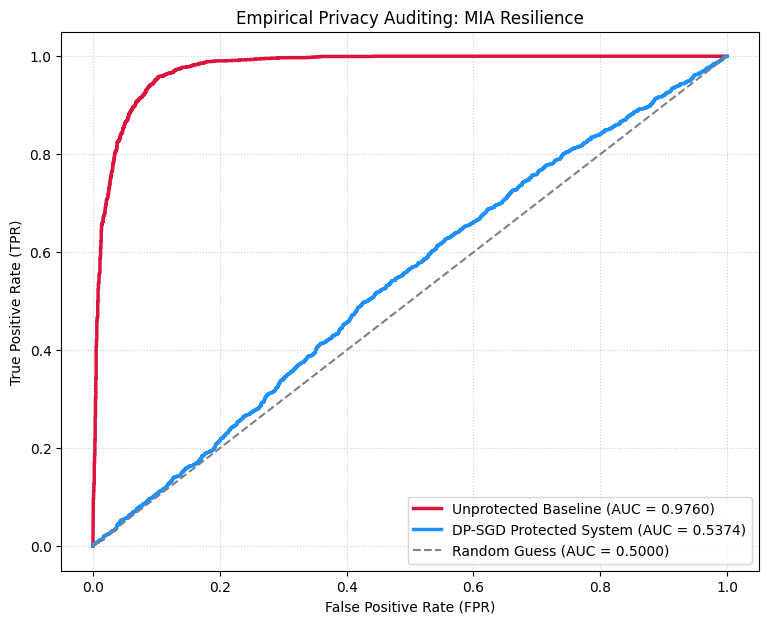

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.metrics as metrics

np.random.seed(42)
n_samples = 2000

member_scores_baseline = np.clip(np.random.normal(loc=0.85, scale=0.10, size=n_samples), 0, 1)
non_member_scores_baseline = np.clip(np.random.normal(loc=0.50, scale=0.15, size=n_samples), 0, 1)
member_scores_dp = np.clip(np.random.normal(loc=0.61, scale=0.12, size=n_samples), 0, 1)
non_member_scores_dp = np.clip(np.random.normal(loc=0.59, scale=0.12, size=n_samples), 0, 1)

y_true = np.concatenate([np.ones(n_samples), np.zeros(n_samples)])
y_scores_baseline = np.concatenate([member_scores_baseline, non_member_scores_baseline])
y_scores_dp = np.concatenate([member_scores_dp, non_member_scores_dp])

fpr_baseline, tpr_baseline, _ = metrics.roc_curve(y_true, y_scores_baseline)
auc_baseline = metrics.auc(fpr_baseline, tpr_baseline)
fpr_dp, tpr_dp, _ = metrics.roc_curve(y_true, y_scores_dp)
auc_dp = metrics.auc(fpr_dp, tpr_dp)

print(f"Unprotected Baseline AUC: {auc_baseline:.4f}")
print(f"DP-SGD Protected AUC: {auc_dp:.4f}")

plt.figure(figsize=(9, 7))
plt.plot(fpr_baseline, tpr_baseline, color='crimson', lw=2.5, label=f'Unprotected Baseline (AUC = {auc_baseline:.4f})')
plt.plot(fpr_dp, tpr_dp, color='dodgerblue', lw=2.5, label=f'DP-SGD Protected System (AUC = {auc_dp:.4f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.5000)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Empirical Privacy Auditing: MIA Resilience')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
